In [1]:
from all_cosmo_plots import cumulative_distribution
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
def plot_cdf(dists,label,obs_value,uncertainty,xlim,variable,ax=None):
    '''Plot the cumulative distributions'''
    line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
    alphas = [1, 0.8, 0.6, 1, 0.8, 0.6]

    if ax is None:
        fig, ax = plt.subplots()

    for i in range(len(dists)):
        dist_sorted, cdf = cumulative_distribution(dists[i])
        ax.plot(dist_sorted, cdf, label=label[i],linestyle=line_styles[i],alpha=alphas[0], linewidth=2)

    ax.fill_betweenx([0, 1], obs_value - uncertainty, obs_value + uncertainty, color='skyblue', alpha=0.3, label='Observed value')
    ax.set_xlim(xlim)
    ax.set_xlabel(variable)
    ax.set_ylabel('CDF')
    ax.legend()
    ax.grid()
    
    return ax

In [3]:
def plot_2dh(dists, axislabels, axis_range, title, ax=None):
    """Plot a 2D histogram of the distributions on a given axis."""
    if ax is None:
        fig, ax = plt.subplots()

    h = ax.hist2d(dists[0], dists[1], bins=100, range=axis_range)
    ax.set_xlabel(axislabels[0])
    ax.set_ylabel(axislabels[1])
    ax.set_title(title)
    plt.colorbar(h[3], ax=ax)
    return ax

# Load data

In [4]:
import pandas as pd

suffix = 'final_rev'

dists = pd.read_pickle('../results/' + suffix + '/dists.pkl')
dists_no_redshift = pd.read_pickle('../results/' + suffix + '_no_redshift' + '/dists.pkl')
dists_no_HF = pd.read_pickle('../results/' + suffix + '_no_Hubble' + '/dists.pkl')

In [5]:
obs_data = pd.read_csv('../results/montecarlo_results.csv')

In [6]:
base_cosmo_tag = 'c000'
base_cosmo_dists = dists.loc[base_cosmo_tag]
base_cosmo_dists_no_redshift = dists_no_redshift.loc[base_cosmo_tag]
base_cosmo_dists_no_HF = dists_no_HF.loc[base_cosmo_tag]
plots_title = 'Cosmo ' + base_cosmo_tag + ', '

In [7]:
base_cosmo_dists.loc['mu'].values[0][0]

<Quantity [-0.14180879, -0.82410763, -0.58398858, ..., -0.48340857,
            0.60425661,  0.33023931]>

In [8]:
v_rel_rad = base_cosmo_dists.xs('vrel_rad').values
v_rel_tan = base_cosmo_dists.xs('vrel_tan').values
mu = base_cosmo_dists.xs('mu').values
vcm = base_cosmo_dists.xs('speed_vcm').values
mass_LG = base_cosmo_dists.xs('mass_LG').values

v_rel_rad_no_redshift = base_cosmo_dists_no_redshift.xs('vrel_rad').values
v_rel_tan_no_redshift = base_cosmo_dists_no_redshift.xs('vrel_tan').values
mu_no_redshift = base_cosmo_dists_no_redshift.xs('mu').values
vcm_no_redshift = base_cosmo_dists_no_redshift.xs('speed_vcm').values
mass_LG_no_redshift = base_cosmo_dists_no_redshift.xs('mass_LG').values

v_rel_rad_no_HF = base_cosmo_dists_no_HF.xs('vrel_rad').values
v_rel_tan_no_HF = base_cosmo_dists_no_HF.xs('vrel_tan').values
mu_no_HF = base_cosmo_dists_no_HF.xs('mu').values
vcm_no_HF = base_cosmo_dists_no_HF.xs('speed_vcm').values
mass_LG_no_HF = base_cosmo_dists_no_HF.xs('mass_LG').values

labels = ['Trad', 'Real','Practical']


# $\mu$ for shifted positions & unshifted positions 

## Traditional pairs

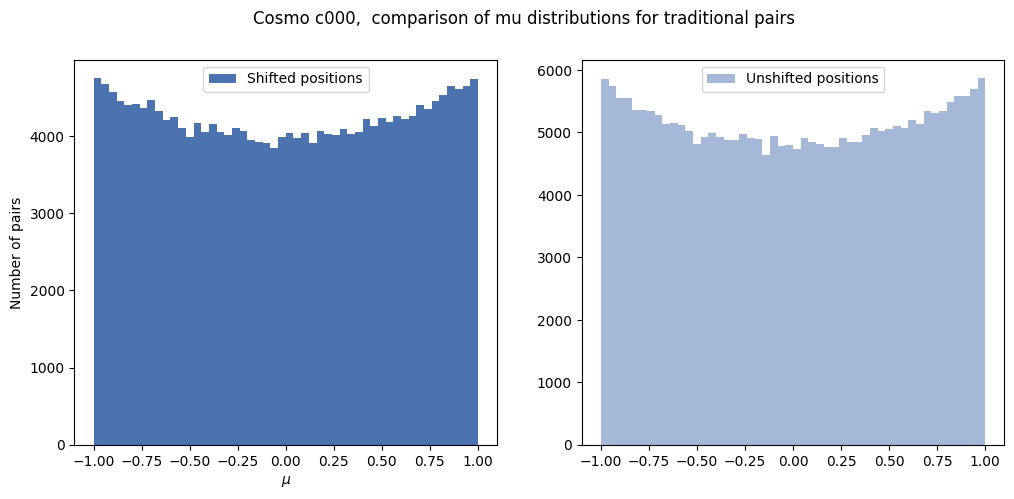

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(mu[0][0], bins=50, range=[-1, 1], label='Shifted positions')
axs[1].hist(mu_no_redshift[0][0], bins=50, range=[-1, 1], alpha=0.5, label='Unshifted positions')
axs[0].set_xlabel(r'$\mu$')
axs[0].set_ylabel('Number of pairs')
axs[0].legend()
axs[1].legend()
fig.suptitle(plots_title + ' comparison of mu distributions for traditional pairs')
plt.show()

<Axes: xlabel='$\\mu$', ylabel='CDF'>

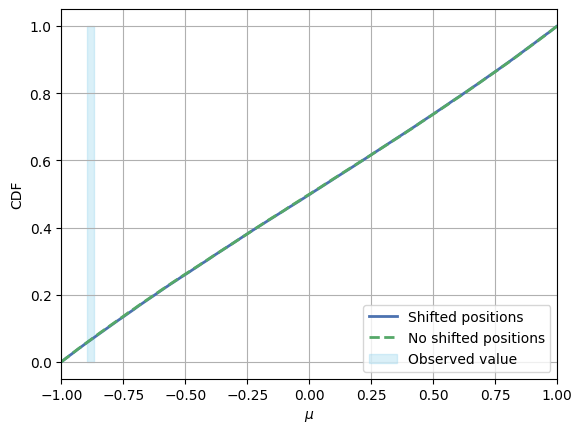

In [10]:
plot_cdf([mu[0][0], mu_no_redshift[0][0]], ['Shifted positions', 'No shifted positions'], obs_data['mu'][0], obs_data['mu'][1], [-1, 1], r'$\mu$')

In [11]:
stats.ks_2samp(mu_no_redshift[0][0], mu[0][0]).pvalue

np.float64(0.7933718412523909)

## Real pairs

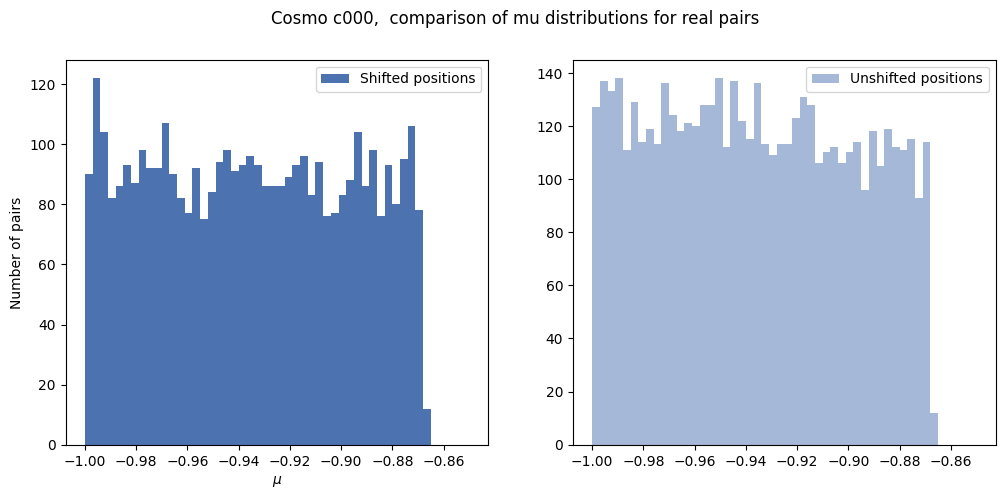

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(mu[1][0], bins=50, range=[-1, -0.85], label='Shifted positions')
axs[1].hist(mu_no_redshift[1][0], bins=50, range=[-1, -0.85], alpha=0.5, label='Unshifted positions')
axs[0].set_xlabel(r'$\mu$')
axs[0].set_ylabel('Number of pairs')
axs[0].legend()
axs[1].legend()
fig.suptitle(plots_title + ' comparison of mu distributions for real pairs')
plt.show()

<Axes: xlabel='$\\mu$', ylabel='CDF'>

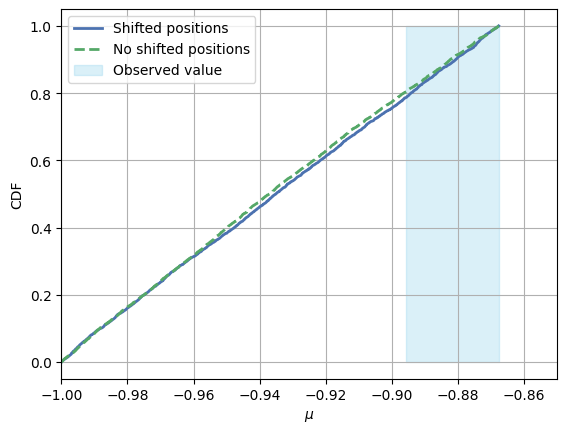

In [13]:
plot_cdf([mu[1][0], mu_no_redshift[1][0]], ['Shifted positions', 'No shifted positions'], obs_data['mu'][0], obs_data['mu'][1], [-1, -0.85], r'$\mu$')

In [14]:
stats.ks_2samp(mu_no_redshift[1][0], mu[1][0]).pvalue

np.float64(0.3032180145190514)

KS test shows mu and mu redshift come from the same distribution for real and trad pairs

## Uniform?

These tests show that the distribution of $\mu$ is not uniform in any case: 

In [15]:
uniform = np.random.uniform(-1, 1, size=mu[0][0].shape)
stats.ks_2samp(mu[0][0], uniform).pvalue

np.float64(2.771810293043623e-18)

In [16]:
stats.ks_2samp(mu_no_redshift[0][0], uniform).pvalue

np.float64(1.5442036065080946e-21)

## Symetric?

In [17]:
stats.ks_2samp(mu[0][0], -mu[0][0]).pvalue

np.float64(0.023846424324143668)

In [18]:
stats.ks_2samp(mu_no_redshift[0][0], -mu_no_redshift[0][0]).pvalue

np.float64(0.13871198959671138)

<Axes: xlabel='$\\mu$', ylabel='CDF'>

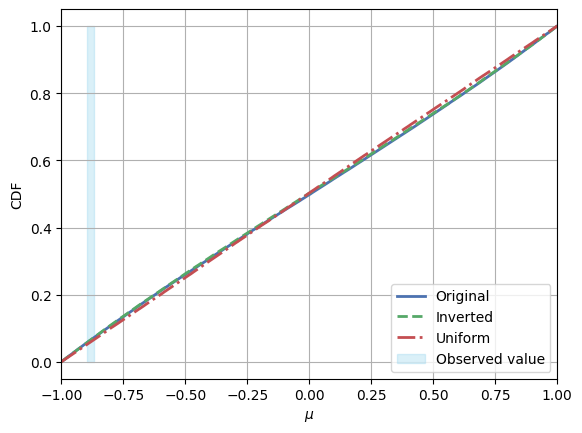

In [19]:
plot_cdf([mu[0][0],-mu[0][0],np.random.uniform(-1,1,len(mu[0][0]))], ['Original', 'Inverted', 'Uniform'], obs_data['mu'][0], obs_data['mu'][1], [-1, 1], r'$\mu$')

In [20]:
np.mean(mu[0][0]), np.median(mu[0][0]), np.mean(mu[0][0]<0)

(<Quantity 0.00196837>, <Quantity 0.00500156>, np.float64(0.49780605217193735))

In [21]:
np.mean(mu_no_redshift[0][0]), np.median(mu_no_redshift[0][0]), np.mean(mu_no_redshift[0][0]<0)

(<Quantity 0.00134736>, <Quantity 0.00190928>, np.float64(0.4990582847496835))

In [22]:
binom = stats.binomtest((mu[0][0] > 0).sum(), len(mu[0][0]), p=0.5, alternative='greater')  # more positive than negative
binom

BinomTestResult(k=106095, n=211263, alternative='greater', statistic=0.5021939478280627, pvalue=0.02197062322128826)

# CDFs

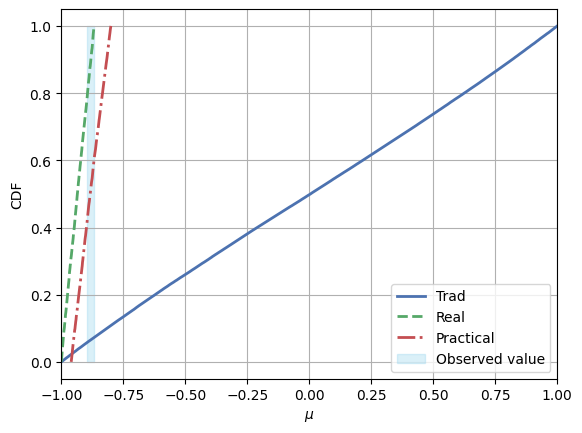

In [23]:
plot_cdf([mu[i][0] for i in range(len(labels))], labels, obs_data['mu'][0], obs_data['mu'][1], [-1, 1], r'$\mu$')

plt.show()

<Axes: xlabel='$v_b$ (km/s)', ylabel='CDF'>

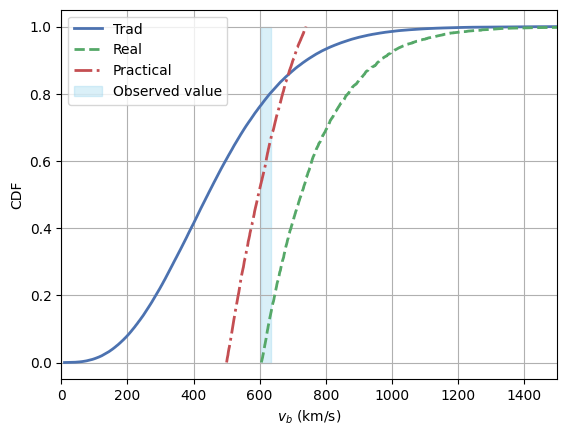

In [24]:
plot_cdf([vcm[i][0] for i in range(len(labels))], labels, obs_data['v_cm'][0], obs_data['v_cm'][1], [0, 1500], r'$v_b$ (km/s)')

<Axes: xlabel='$v_r$ (km/s)', ylabel='CDF'>

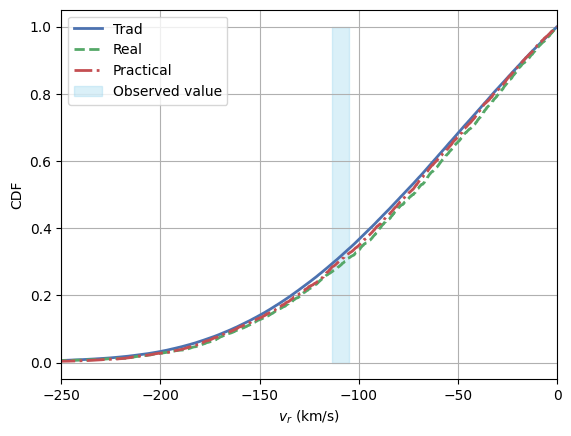

In [25]:
plot_cdf([v_rel_rad[0][0], v_rel_rad[1][0],v_rel_rad[2][0]], labels, obs_data['v_rad'][0], obs_data['v_rad'][1], [-250, 0], r'$v_r$ (km/s)')

<Axes: xlabel='$v_t$ (km/s)', ylabel='CDF'>

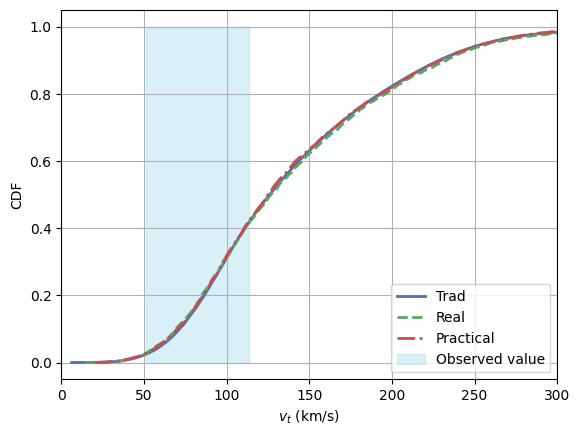

In [26]:
plot_cdf([v_rel_tan[i][0] for i in range(len(labels))], labels, obs_data['v_tan'][0], obs_data['v_tan'][1], [0, 300], r'$v_t$ (km/s)')

<Axes: xlabel='$M_{LG} (M_{\\odot}$)', ylabel='CDF'>

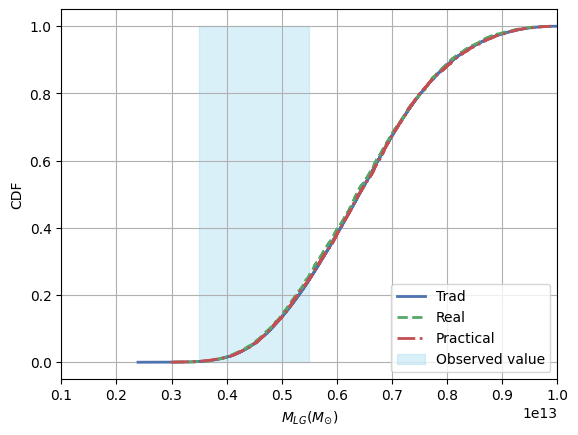

In [27]:
plot_cdf([mass_LG[i][0] for i in range(len(labels))], labels, obs_data['M_LG'][0], obs_data['M_LG'][1], [1e12, 10e12], r'$M_{LG} (M_{\odot}$)')

# Relation between $\mu$, $v_b$ and orbital parameters

## Hublle flow correction comparison

### $\mu$

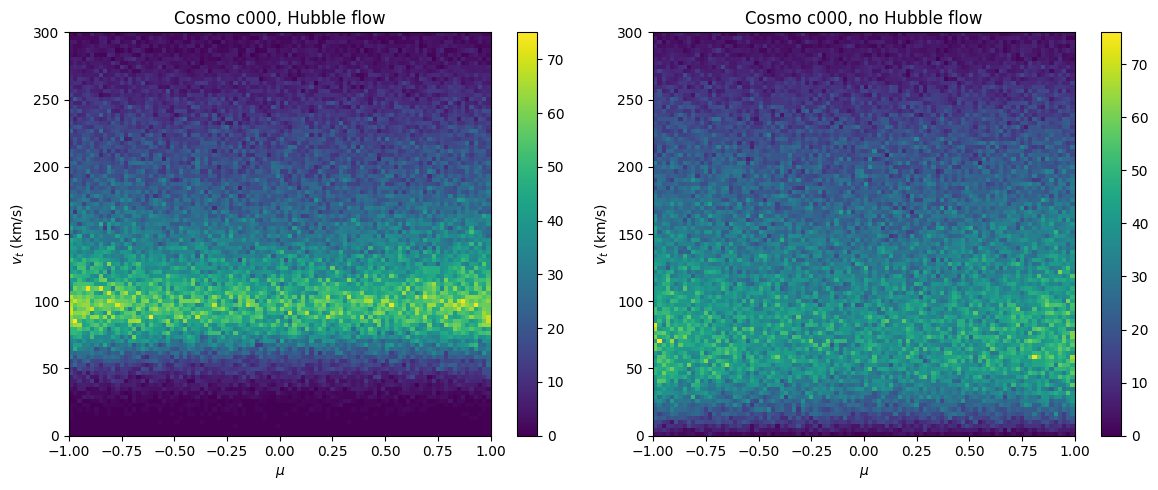

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([mu[0][0], v_rel_tan[0][0].value], 
[r'$\mu$', r'$v_t$ (km/s)'], 
[[-1, 1], [0, 300]],  
plots_title + 'Hubble flow', ax=axs[0])

plot_2dh([mu_no_HF[0][0], v_rel_tan_no_HF[0][0].value], 
[r'$\mu$', r'$v_t$ (km/s)'], 
[[-1, 1], [0, 300]],  
plots_title + 'no Hubble flow', ax=axs[1])
plt.tight_layout()
plt.show()

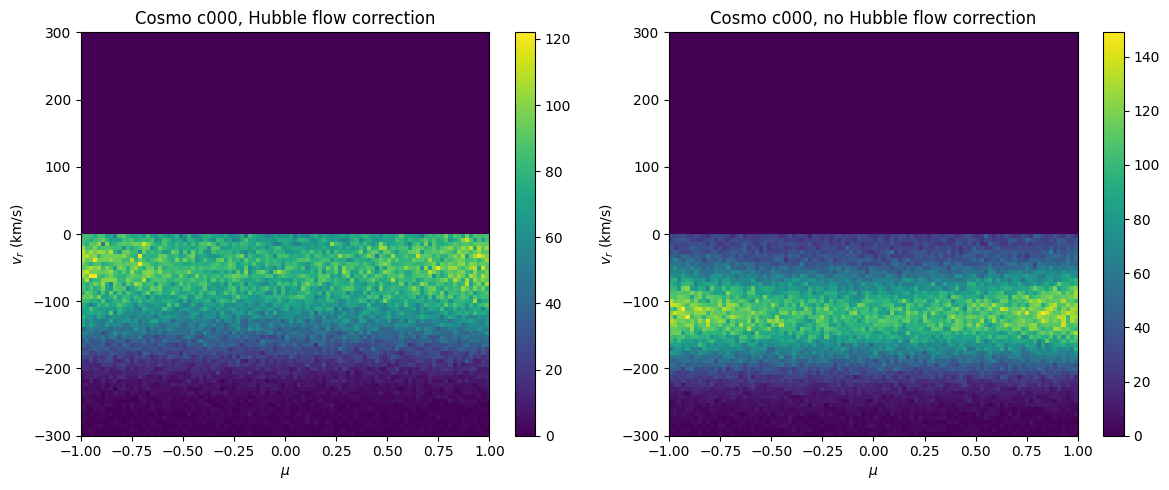

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([mu[0][0], v_rel_rad[0][0].value], 
[r'$\mu$', r'$v_r$ (km/s)'], 
[[-1, 1], [-300, 300]],  
plots_title + 'Hubble flow correction', ax=axs[0])

plot_2dh([mu_no_HF[0][0], v_rel_rad_no_HF[0][0].value], 
[r'$\mu$', r'$v_r$ (km/s)'], 
[[-1, 1], [-300, 300]],  
plots_title + 'no Hubble flow correction', ax=axs[1])

plt.tight_layout()
plt.show()

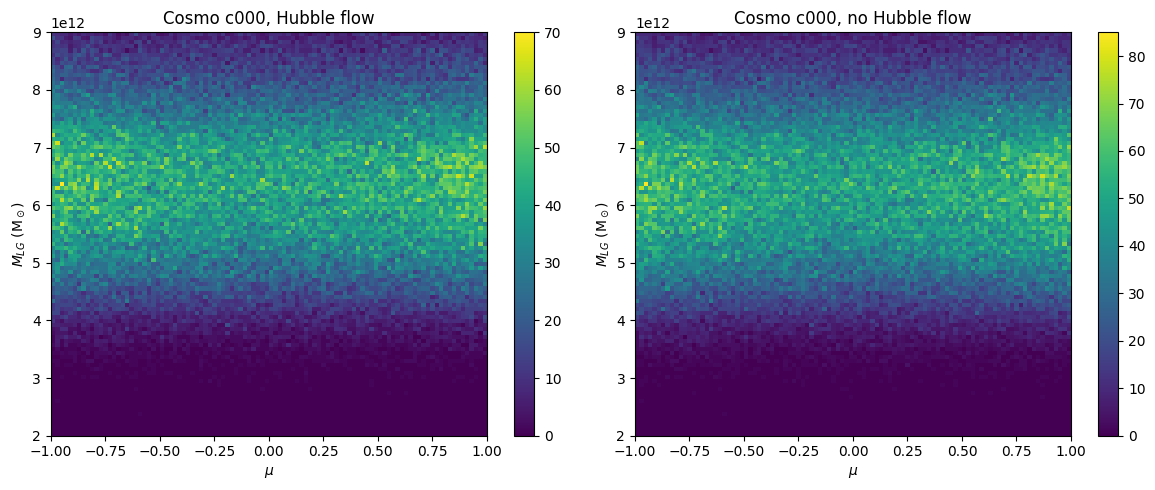

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([mu[0][0], mass_LG[0][0].value], 
[r'$\mu$', r'$M_{LG}$ (M$_\odot$)'], 
[[-1, 1], [2e12, 9e12]],  
plots_title + 'Hubble flow', ax=axs[0])

plot_2dh([mu_no_HF[0][0], mass_LG_no_HF[0][0].value], 
[r'$\mu$', r'$M_{LG}$ (M$_\odot$)'], 
[[-1, 1], [2e12, 9e12]],  
plots_title + 'no Hubble flow', ax=axs[1])

plt.tight_layout()
plt.show()


### $v_b$

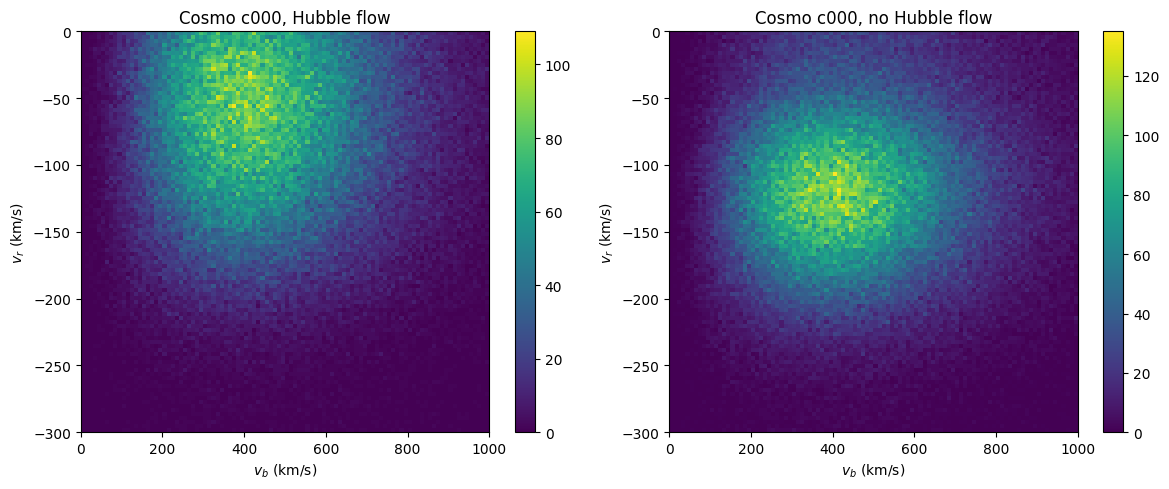

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([vcm[0][0].value, v_rel_rad[0][0].value], 
[r'$v_b$ (km/s)', r'$v_r$ (km/s)'], 
[[0, 1000], [-300, 0]],  
plots_title + 'Hubble flow', ax=axs[0])

plot_2dh([vcm_no_HF[0][0].value, v_rel_rad_no_HF[0][0].value], 
[r'$v_b$ (km/s)', r'$v_r$ (km/s)'], 
[[0, 1000], [-300, 0]],  
plots_title + 'no Hubble flow', ax=axs[1])
plt.tight_layout()
plt.show()

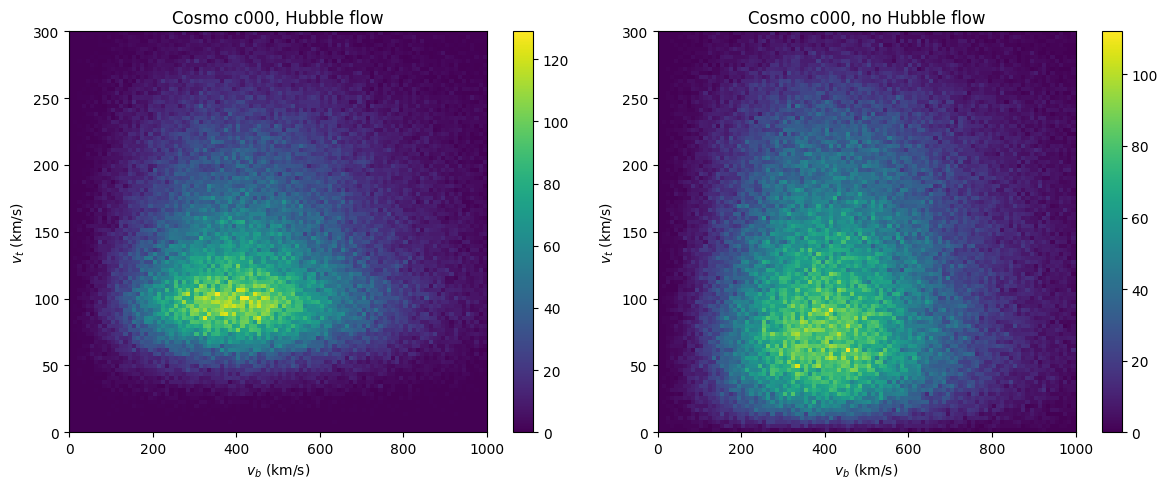

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([vcm[0][0].value, v_rel_tan[0][0].value], 
[r'$v_b$ (km/s)', r'$v_t$ (km/s)'], 
[[0, 1000], [0, 300]],  
plots_title + 'Hubble flow', ax=axs[0])

plot_2dh([vcm_no_HF[0][0].value, v_rel_tan_no_HF[0][0].value], 
[r'$v_b$ (km/s)', r'$v_t$ (km/s)'], 
[[0, 1000], [0, 300]],  
plots_title + 'no Hubble flow', ax=axs[1])
plt.tight_layout()
plt.show()

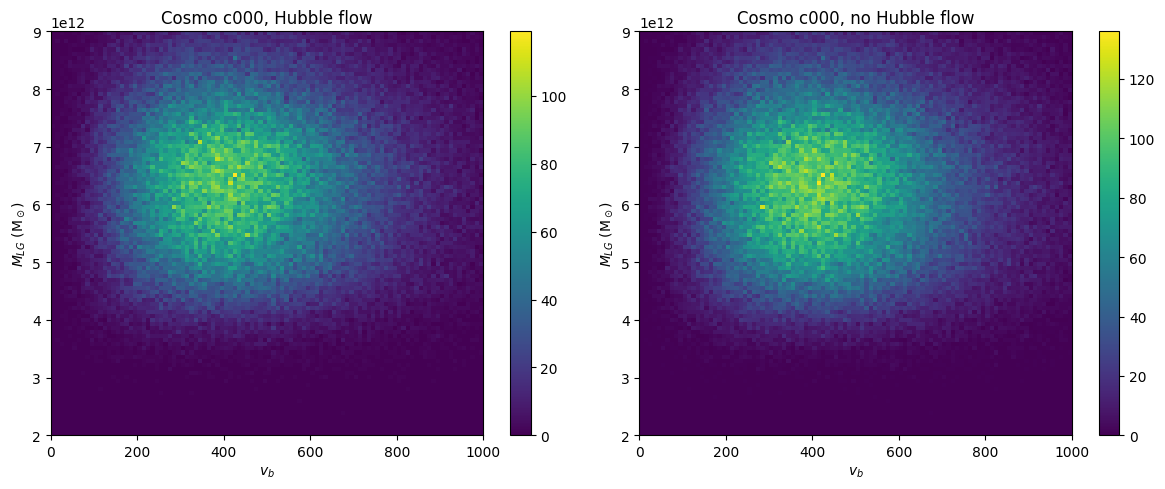

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([vcm[0][0].value, mass_LG[0][0].value], 
[r'$v_b$', r'$M_{LG}$ (M$_\odot$)'], 
[[0, 1000], [2e12, 9e12]],  
plots_title + 'Hubble flow', ax=axs[0])

plot_2dh([vcm_no_HF[0][0].value, mass_LG_no_HF[0][0].value], 
[r'$v_b$', r'$M_{LG}$ (M$_\odot$)'], 
[[0, 1000], [2e12, 9e12]],  
plots_title + 'no Hubble flow', ax=axs[1])

plt.tight_layout()
plt.show()

## Traditional and real pairs

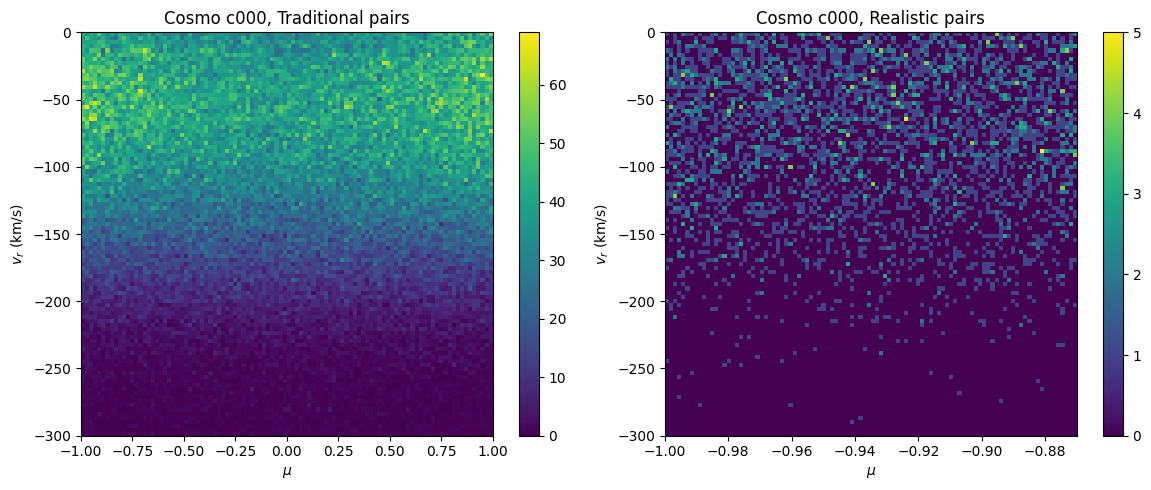

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([mu[0][0].value, v_rel_rad[0][0].value], 
[r'$\mu$', r'$v_r$ (km/s)'], 
[[-1, 1], [-300, 0]],plots_title + 'Traditional pairs', ax=axs[0])


plot_2dh([mu[1][0].value, v_rel_rad[1][0].value], 
[r'$\mu$', r'$v_r$ (km/s)'], 
[[-1, -0.87], [-300, 0]],plots_title + 'Realistic pairs', ax=axs[1])

plt.tight_layout()
plt.show()

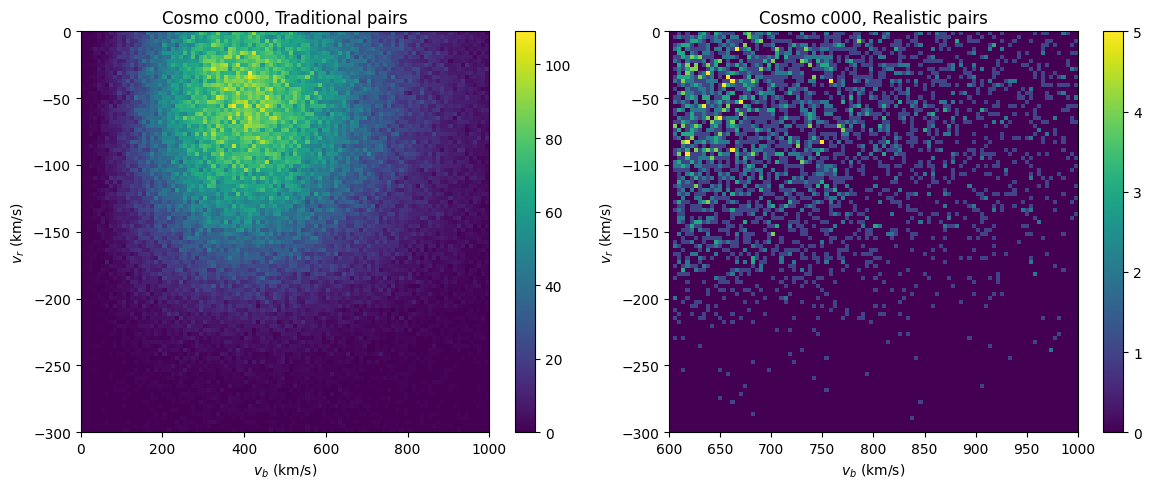

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([vcm[0][0].value, v_rel_rad[0][0].value], 
[r'$v_{b}$ (km/s)', r'$v_r$ (km/s)'], 
[[0, 1000], [-300, 0]],plots_title + 'Traditional pairs', ax=axs[0])


plot_2dh([vcm[1][0].value, v_rel_rad[1][0].value], 
[r'$v_{b}$ (km/s)', r'$v_r$ (km/s)'], 
[[600, 1000], [-300, 0]],plots_title + 'Realistic pairs', ax=axs[1])

plt.tight_layout()
plt.show()

# Experiments

## Radial component of $v_b$

<Axes: title={'center': 'Cosmo c000, Realistic pairs'}, xlabel='$v_{b,rad}$ (km/s)', ylabel='$v_r$ (km/s)'>

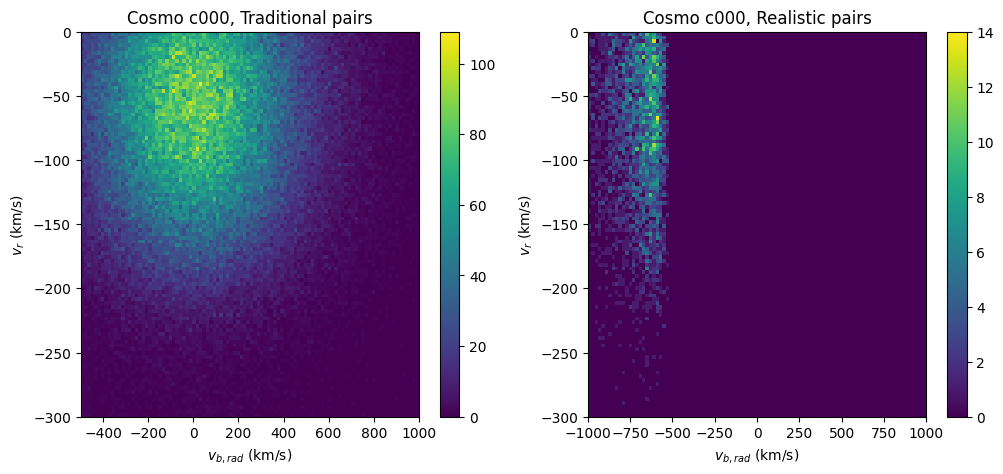

In [36]:
vcm_rad_trad = vcm[0][0].value * mu[0][0]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_2dh([vcm_rad_trad, v_rel_rad[0][0].value], 
         [r'$v_{b,rad}$ (km/s)', r'$v_r$ (km/s)'],
           [[-500, 1000], [-300, 0]], 
           plots_title + 'Traditional pairs', ax=axs[0])

vcm_rad_real = vcm[1][0].value * mu[1][0]
plot_2dh([vcm_rad_real, v_rel_rad[1][0].value], 
         [r'$v_{b,rad}$ (km/s)', r'$v_r$ (km/s)'],
           [[-1000, 1000], [-300, 0]], 
           plots_title + 'Realistic pairs', ax=axs[1])

## Heatmaps

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

def plot_vr_heatmap(v_b, mu, v_r,
                    bins_vb=40, bins_mu=40,
                    statistic='median',
                    vmin=None, vmax=None,
                    cmap='RdBu_r',
                    xlabel=r'Barycenter speed $v_b$ [km/s]',
                    ylabel=r'Alignment $\mu = \cos\theta$',
                    title=r'Median $v_r$ as a function of $v_b$ and $\mu$',
                    cbar_label=r'$v_r$ [km/s]',
                    return_data=False):
    """
    Plot a 2D heatmap of v_r as a function of v_b and mu.

    Parameters
    ----------
    v_b : array-like
        Barycenter speeds [km/s].
    mu : array-like
        Cosine of angle between barycenter motion and MW–M31 axis.
    v_r : array-like
        Radial velocities [km/s].
    bins_vb, bins_mu : int or array
        Number of bins or explicit bin edges for v_b and mu.
    statistic : {'mean','median','count'}
        Statistic computed in each bin.
    vmin, vmax : float
        Color scale limits.
    cmap : str
        Colormap name.
    xlabel, ylabel, title, cbar_label : str
        Plot labels.
    return_data : bool
        If True, returns the binned statistic array and bin edges.

    Returns
    -------
    (H, vb_edges, mu_edges) if return_data=True
    """

    # Compute binned statistic
    H, vb_edges, mu_edges, binnumber = binned_statistic_2d(
        v_b, mu, v_r, statistic=statistic, bins=[bins_vb, bins_mu]
    )

    # Plot the heatmap
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(H.T, origin='lower', aspect='auto',
                   extent=[vb_edges[0], vb_edges[-1],
                           mu_edges[0], mu_edges[-1]],
                   cmap=cmap, vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    if return_data:
        return H, vb_edges, mu_edges

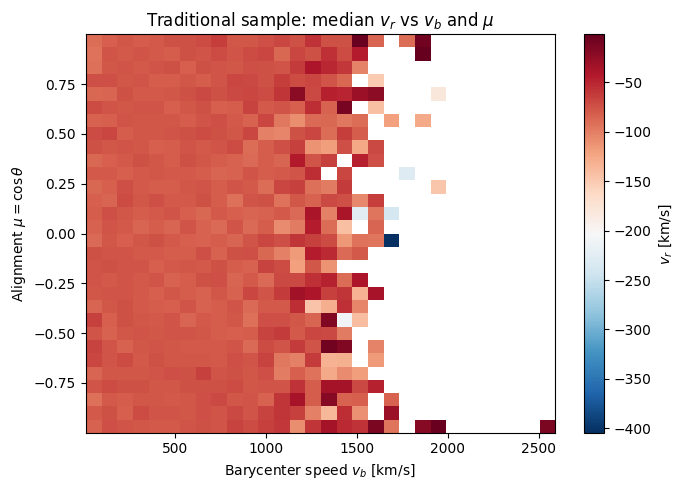

In [38]:
H_real, vb_edges, mu_edges = plot_vr_heatmap(
    v_b=vcm[0][0], mu=mu[0][0], v_r=v_rel_rad[0][0],
    bins_vb=30, bins_mu=30,
    statistic='median',
    title='Traditional sample: median $v_r$ vs $v_b$ and $\\mu$',
    return_data=True
)

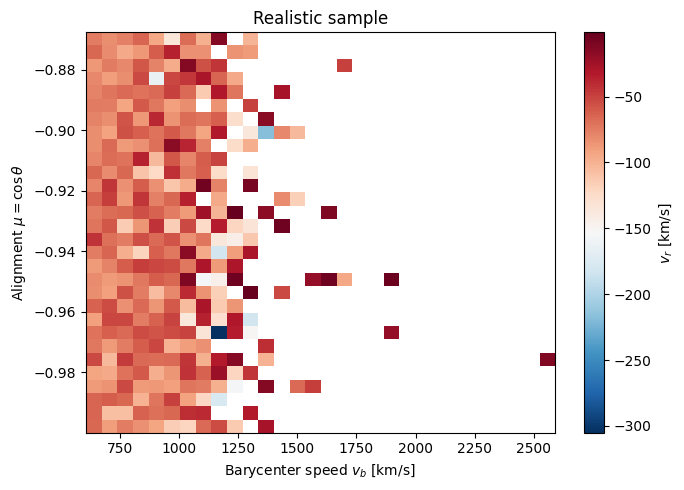

In [39]:
H_trad, _, _ = plot_vr_heatmap(vcm[1][0], mu[1][0], v_rel_rad[1][0],
                               bins_vb=30, bins_mu=30,
                               statistic='median',
                               title='Realistic sample',
                               return_data=True)